import library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

mambaca file excel

In [6]:
df = pd.read_excel(r'C:\Users\HP\OneDrive\ドキュメント\coffee-shop-analysis\Coffee Shop Sales.xlsx')
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


cek kolom

In [7]:
df.columns

Index(['transaction_id', 'transaction_date', 'transaction_time',
       'transaction_qty', 'store_id', 'store_location', 'product_id',
       'unit_price', 'product_category', 'product_type', 'product_detail'],
      dtype='str')

cek produk terlaris (bisa di modifikasi mau menampilkan brapa produk yang paling sering dijual. di contoh ini ada 10 produk terlaris)

In [9]:
top_products = df['product_type'].value_counts().head(10)

top_products

product_type
Brewed Chai tea          17183
Gourmet brewed coffee    16912
Barista Espresso         16403
Hot chocolate            11468
Brewed Black tea         11350
Brewed herbal tea        11245
Scone                    10173
Organic brewed coffee     8489
Drip coffee               8477
Premium brewed coffee     8135
Name: count, dtype: int64

grafik produk terlaris

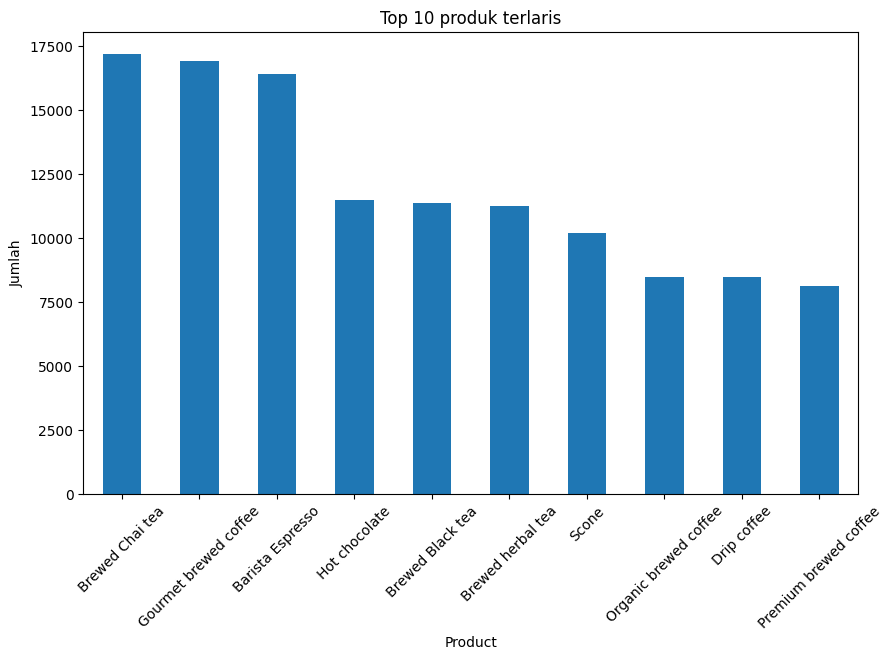

In [12]:
plt.figure(figsize=(10, 6))
top_products.plot(kind='bar')
plt.title('Top 10 produk terlaris')
plt.xlabel('Product')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)
plt.show()

mengubah kolom waktu untuk mencari jam paling ramai.

In [14]:
df['transaction_time'] = pd.to_datetime(
    df['transaction_time'].astype(str)
)
df['hour']=df['transaction_time'].dt.hour
df[['transaction_time','hour']].head()

C:\Users\HP\AppData\Local\Temp\ipykernel_16876\2448831230.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['transaction_time'] = pd.to_datetime(


,transaction_time,hour
0,2026-08-12 07:06:11,7
1,2026-08-12 07:08:56,7
2,2026-08-12 07:14:04,7
3,2026-08-12 07:20:24,7
4,2026-08-12 07:22:41,7


menghitung transaksi per jam

In [15]:
hourly_sales = df.groupby('hour').size()

hourly_sales

hour
6      4594
7     13428
8     17654
9     17764
10    18545
11     9766
12     8708
13     8714
14     8933
15     8979
16     9093
17     8745
18     7498
19     6092
20      603
dtype: int64

melihat grafik jam paling ramai

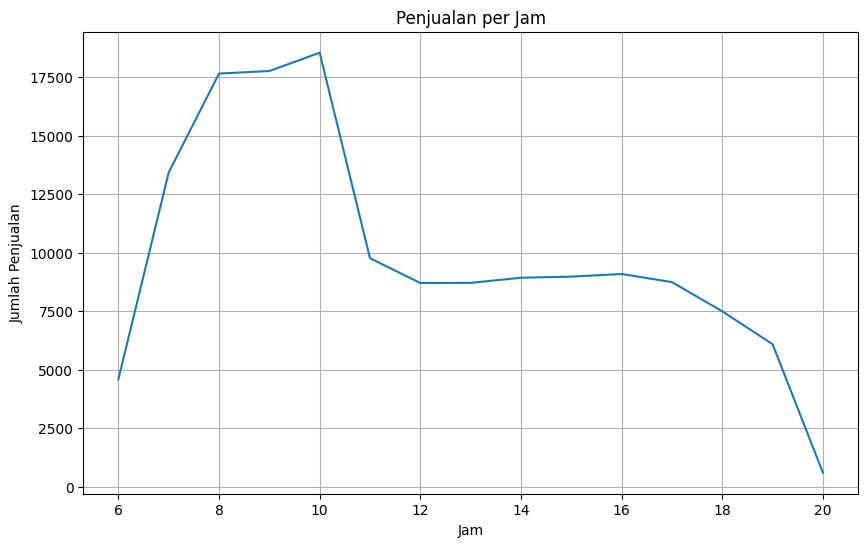

In [16]:
plt.figure(figsize=(10, 6))
hourly_sales.plot(kind='line')
plt.title('Penjualan per Jam')
plt.xlabel('Jam')
plt.ylabel('Jumlah Penjualan')
plt.grid(True)

plt.show()

INSIGHT 1: 
produk dengan penjualan tertinggi adalah Brewed Chai Tea disusul dengan kategori kopi tertentu yang paling sering dibeli pelanggan.

INSIGHT 2:
transaksi paling ramai dilakukan di pagi hari pada pukul 6-10.

INSIGHT 3:
coffee shop dapat menambah stok dan mempercepat pelayanan pada jam jam ramai pengunjung tersebut.